In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("../Data/solar_clean.csv", parse_dates=['Date-Hour(NMT)'])

ts = df['Date-Hour(NMT)']
for name, values, period in [('hour', ts.dt.hour, 24), ('doy', ts.dt.dayofyear, 365.25)]:
    df[f'{name}_sin'] = np.sin(2*np.pi*values/period)
    df[f'{name}_cos'] = np.cos(2*np.pi*values/period)

In [19]:
FEATURES = ['WindSpeed','Sunshine','AirPressure','Radiation','AirTemperature',
            'RelativeAirHumidity','hour_sin','hour_cos','doy_sin','doy_cos']
X, y = df[FEATURES], df['SystemProduction']

In [9]:

split_index = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print("test period:", df['Date-Hour(NMT)'].iloc[split_index], "→",
      df['Date-Hour(NMT)'].iloc[-1])
print("mean production — train:", round(y_train.mean()), "| test:", round(y_test.mean()))

test period: 2017-10-24 04:00:00 → 2017-12-31 23:00:00
mean production — train: 890 | test: 74


In [10]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.base import clone

tscv = TimeSeriesSplit(n_splits=5)

def cv_score(model, X, y):
    rows = []
    for tr, te in tscv.split(X):
        m = clone(model).fit(X.iloc[tr], y.iloc[tr])
        p = np.clip(m.predict(X.iloc[te]), 0, None)
        rows.append({'mae':  mean_absolute_error(y.iloc[te], p),
                     'rmse': np.sqrt(mean_squared_error(y.iloc[te], p)),
                     'r2':   r2_score(y.iloc[te], p)})
    return pd.DataFrame(rows).mean().round(3)

In [11]:
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

baseline_prediction = np.full(len(y_test), y_train.mean())

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_r2 = r2_score(y_test, baseline_prediction)

print("Baseline MAE:", baseline_mae)
print("Baseline R²:", baseline_r2)

hist = y_train.groupby([X_train.index.map(df['Date-Hour(NMT)'].dt.month),
                        X_train.index.map(df['Date-Hour(NMT)'].dt.hour)]).mean()
keys = pd.MultiIndex.from_arrays([df['Date-Hour(NMT)'].dt.month.iloc[split_index:],
                                  df['Date-Hour(NMT)'].dt.hour.iloc[split_index:]])
clim_pred = hist.reindex(keys).fillna(y_train.mean()).to_numpy()
print("Climatology MAE:", round(mean_absolute_error(y_test, clim_pred), 1))

Baseline MAE: 853.8026406401651
Baseline R²: -6.6659267087957135
Climatology MAE: 791.2


In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np


linear_model = LinearRegression()

linear_model.fit(X_train, y_train)


y_pred = linear_model.predict(X_test)

linear_mae = mean_absolute_error(y_test, y_pred)
linear_r2 = r2_score(y_test, y_pred)

print("Linear Regression Results")
print("MAE:", linear_mae)
print("R²:", linear_r2)

Linear Regression Results
MAE: 333.58309316268156
R²: -0.835734555278369


In [13]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)


rf_pred = rf_model.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Results")
print("MAE:", rf_mae)
print("R²:", rf_r2)

Random Forest Results
MAE: 65.68849858414043
R²: 0.47686517375093074


In [21]:
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

results = pd.DataFrame({
    'Mean baseline':     cv_score(DummyRegressor(strategy='mean'), X, y),
    'Linear Regression': cv_score(LinearRegression(), X, y),
    'Random Forest':     cv_score(RandomForestRegressor(
                             n_estimators=300, min_samples_leaf=2,
                             random_state=42, n_jobs=-1), X, y),
}).T
results

,mae,rmse,r2
Mean baseline,1120.826,1629.806,-2.824
Linear Regression,505.596,883.279,0.314
Random Forest,374.406,739.861,0.659


In [20]:
print(FEATURES)
print(len(FEATURES))
print(X.shape)

['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature', 'RelativeAirHumidity', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']
10
(8256, 10)


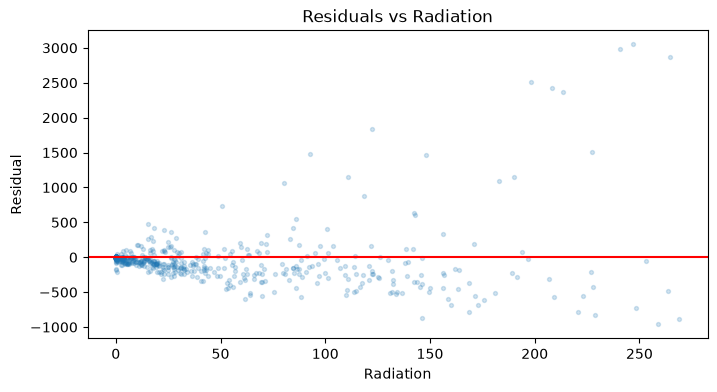

In [22]:
rf_model = RandomForestRegressor(n_estimators=300, min_samples_leaf=2,
                                 random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

resid = y_test.values - np.clip(rf_pred, 0, None)
plt.figure(figsize=(8,4))
plt.scatter(X_test['Radiation'], resid, alpha=0.2, s=8)
plt.axhline(0, color='r'); plt.xlabel('Radiation'); plt.ylabel('Residual')
plt.title('Residuals vs Radiation'); plt.show()



In [23]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    {'n_estimators':     [200, 300, 400],
     'max_depth':        [12, 16, 20, None],
     'min_samples_leaf': [1, 2, 5, 10],
     'max_features':     [0.4, 0.6, 0.8, 1.0]},
    n_iter=20, scoring='neg_mean_absolute_error',
    cv=tscv, random_state=42, n_jobs=-1)

search.fit(X, y)
print(search.best_params_)
print("CV MAE:", round(-search.best_score_, 1))

{'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 0.8, 'max_depth': 16}
CV MAE: 366.0


In [24]:
final_model = search.best_estimator_
final_model.fit(X, y)
print("trained on", len(X), "rows")

trained on 8256 rows


In [25]:
import json, joblib, sklearn
from pathlib import Path

out = Path("../models/v2"); out.mkdir(parents=True, exist_ok=True)
joblib.dump(final_model, out/"model.pkl", compress=3)
json.dump({"features": FEATURES, "target": "SystemProduction", "unit": "Wh",
           "cv_mae": round(-search.best_score_, 2), "n_rows": len(X), "seed": 42,
           "sklearn": sklearn.__version__},
          open(out/"metadata.json","w"), indent=2)
print(round((out/"model.pkl").stat().st_size/1e6, 1), "MB")

4.3 MB


In [27]:
m = joblib.load("../models/v2/model.pkl")
print(m.predict(X.head(3)))
print(json.load(open("../models/v2/metadata.json"))["features"])

[2.35325997e-05 2.35325997e-05 2.35325997e-05]
['WindSpeed', 'Sunshine', 'AirPressure', 'Radiation', 'AirTemperature', 'RelativeAirHumidity', 'hour_sin', 'hour_cos', 'doy_sin', 'doy_cos']


In [28]:
# v1 — original approach: raw data, integer Hour/Month, untuned
raw = pd.read_csv("../Data/Solar Power Plant Data.csv")
raw['Date-Hour(NMT)'] = pd.to_datetime(raw['Date-Hour(NMT)'], format='%d.%m.%Y-%H:%M')
raw['Hour']  = raw['Date-Hour(NMT)'].dt.hour
raw['Month'] = raw['Date-Hour(NMT)'].dt.month

FEATURES_V1 = ['WindSpeed','Sunshine','AirPressure','Radiation',
               'AirTemperature','RelativeAirHumidity','Hour','Month']
X1, y1 = raw[FEATURES_V1], raw['SystemProduction']

model_v1 = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1).fit(X1, y1)
mae_v1 = cv_score(model_v1, X1, y1)['mae']

out1 = Path("../models/v1"); out1.mkdir(parents=True, exist_ok=True)
joblib.dump(model_v1, out1/"model.pkl", compress=3)
json.dump({"features": FEATURES_V1, "target": "SystemProduction", "unit": "Wh",
           "cv_mae": round(mae_v1, 2), "n_rows": len(X1), "seed": 42,
           "sklearn": sklearn.__version__, "note": "raw data, no cleaning, no tuning"},
          open(out1/"metadata.json", "w"), indent=2)

print("v1 CV MAE:", round(mae_v1, 1))

v1 CV MAE: 476.9
